# Task 3 — Explainability (SHAP + LIME)

**Group 11 · CSE475 Machine Learning · Summer 2026**

This notebook is a **standalone extract** of the explainability pipeline from
`Group11_FORS_EMG_Task3_GNN_expolit.ipynb`. It:

1. Rebuilds the preprocessing / graph-construction / GNN pipeline needed to reproduce predictions
2. Loads the saved final GNN checkpoint (`models/gnn_final.pt`) if available, otherwise retrains it
3. Picks **one correctly-classified** and **one misclassified** validation sample
4. Explains both samples with **SHAP** (TreeExplainer on an interpretable RF surrogate, trained on
   the same 7 time-domain-statistical features per channel that feed the GNN)
5. Explains the **same two samples** with **LIME**, using a wrapper that queries the actual
   trained GNN's `predict_proba`
6. Compares what SHAP and LIME each highlight as the driving features for the correct vs. the
   wrong prediction

**Note:** Update `DATA_DIR` below to point at your local copy of the FORS-EMG dataset before running.


## 1 · Setup & Imports

In [1]:
# ── Installs (run once) ──
!pip install torch-geometric shap lime scipy scikit-learn -q


In [2]:
import os, re, warnings, itertools
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from collections import defaultdict
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Path — UPDATE ME ──
DATA_DIR = r"C:\Users\Asus\Documents\Group11_Fors_EMG_Project\Fors_EMG_Dataset"

# ── Path to the checkpoint saved by the main Task-3 notebook (optional) ──
CHECKPOINT_PATH = "models/gnn_final.pt"

# ── Constants (must match the main notebook) ──
FS          = 985
WINDOW_SIZE = 492
STRIDE      = 246
N_CH        = 8
N_CLASSES   = 12
PAIRS       = list(combinations(range(N_CH), 2))  # 28 pairs

TRAIN_SUBJECTS = [f'Subject{i}' for i in range(1, 16)]
VAL_SUBJECTS   = ['Subject16', 'Subject17']
TEST_SUBJECTS  = ['Subject18', 'Subject19']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('PyTorch:', torch.__version__)


Device: cuda
PyTorch: 2.10.0


## 2 · Signal Preprocessing & TSD Feature Extraction

In [3]:
# ── Signal preprocessing ──
def make_bandpass(lo=20, hi=450, fs=FS, order=4):
    nyq = fs / 2
    b, a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return b, a

def make_notch(freq=50, q=30, fs=FS):
    b, a = iirnotch(freq / (fs/2), q)
    return b, a

BP_B, BP_A = make_bandpass()
NT_B, NT_A = make_notch()

def preprocess(signal):
    """Bandpass 20-450Hz + Notch 50Hz. signal: (8, 8000)"""
    out = np.zeros_like(signal, dtype=np.float64)
    for ch in range(signal.shape[0]):
        x = filtfilt(BP_B, BP_A, signal[ch].astype(np.float64))
        out[ch] = filtfilt(NT_B, NT_A, x)
    return out

# ── Windowing ──
def make_windows(signal):
    """Returns (n_windows, 8, 492)"""
    starts = range(0, signal.shape[1] - WINDOW_SIZE + 1, STRIDE)
    return np.stack([signal[:, s:s+WINDOW_SIZE] for s in starts])

# ── TSD features (7 per channel) ──
def _tsd_single(x):
    eps = 1e-10
    dx  = np.diff(x, prepend=x[0])
    d2x = np.diff(x, n=2, prepend=[x[0], x[0]])
    m0  = np.sqrt(np.mean(x**2))
    m2  = np.sqrt(np.mean(dx**2))
    m4  = np.sqrt(np.mean(d2x**2))
    spar = np.log(np.abs((np.sqrt(m0)/(m0-m2+eps))*(np.sqrt(m0)-m4+eps)) + eps)
    irf  = np.log(m2/(np.sqrt(m0*m4)+eps) + eps)
    cov  = np.log(np.std(x)/(np.abs(np.mean(x))+eps) + eps)
    tkeo = np.log(np.sum(np.abs(x[1:-1]**2 - x[:-2]*x[2:])) + eps)
    return np.array([m0, m2, m4, spar, irf, cov, tkeo], dtype=np.float32)

def extract_node_features(window):
    """window: (8, 492) -> X: (8, 7)"""
    return np.stack([_tsd_single(window[ch]) for ch in range(N_CH)])

# ── Interpretable feature names (8 channels x 7 TSD stats = 56) ──
TSD_NAMES = ['M0', 'M2', 'M4', 'Sparseness', 'IRF', 'COV', 'TKEO']
FEATURE_NAMES = [f'CH{ch+1}_{f}' for ch in range(N_CH) for f in TSD_NAMES]

print('Preprocessing and feature functions ready.')
print(f'{len(FEATURE_NAMES)} interpretable node features:', FEATURE_NAMES)


Preprocessing and feature functions ready.
56 interpretable node features: ['CH1_M0', 'CH1_M2', 'CH1_M4', 'CH1_Sparseness', 'CH1_IRF', 'CH1_COV', 'CH1_TKEO', 'CH2_M0', 'CH2_M2', 'CH2_M4', 'CH2_Sparseness', 'CH2_IRF', 'CH2_COV', 'CH2_TKEO', 'CH3_M0', 'CH3_M2', 'CH3_M4', 'CH3_Sparseness', 'CH3_IRF', 'CH3_COV', 'CH3_TKEO', 'CH4_M0', 'CH4_M2', 'CH4_M4', 'CH4_Sparseness', 'CH4_IRF', 'CH4_COV', 'CH4_TKEO', 'CH5_M0', 'CH5_M2', 'CH5_M4', 'CH5_Sparseness', 'CH5_IRF', 'CH5_COV', 'CH5_TKEO', 'CH6_M0', 'CH6_M2', 'CH6_M4', 'CH6_Sparseness', 'CH6_IRF', 'CH6_COV', 'CH6_TKEO', 'CH7_M0', 'CH7_M2', 'CH7_M4', 'CH7_Sparseness', 'CH7_IRF', 'CH7_COV', 'CH7_TKEO', 'CH8_M0', 'CH8_M2', 'CH8_M4', 'CH8_Sparseness', 'CH8_IRF', 'CH8_COV', 'CH8_TKEO']


## 3 · Graph Construction (needed to run the GNN forward pass)

In [4]:
# ── Adjacency matrix construction ──
def make_spatial_adj():
    A = np.zeros((N_CH, N_CH), dtype=np.float32)
    for i, j in combinations(range(4), 2):          # elbow group
        A[i, j] = A[j, i] = 1.0
    for i, j in combinations(range(4, 8), 2):        # mid-forearm group
        A[i, j] = A[j, i] = 1.0
    for k in range(4):                                # aligned cross-location pairs
        A[k, k+4] = A[k+4, k] = 1.0
    return A

SPATIAL_ADJ = make_spatial_adj()

def make_correlation_adj(window, threshold=0.3):
    C = np.corrcoef(window)
    A = np.abs(C).astype(np.float32)
    np.fill_diagonal(A, 0)
    A[A < threshold] = 0
    return A

def make_combined_adj(window, threshold=0.3):
    A_corr = make_correlation_adj(window, threshold)
    A = A_corr.copy()
    A = np.maximum(A, SPATIAL_ADJ * 0.5)
    return A

def normalize_adj(A):
    """Symmetric normalisation: D^(-1/2) (A+I) D^(-1/2)"""
    A = A + np.eye(N_CH, dtype=np.float32)
    D = np.diag(A.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D) + 1e-10))
    return D_inv_sqrt @ A @ D_inv_sqrt

print('Graph construction functions ready.')


Graph construction functions ready.


## 4 · Data Loading Pipeline

In [5]:
# ============================================================
# GNN DATA LOADING PIPELINE
# ============================================================

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"\nDataset folder not found!\nCheck DATA_DIR:\n{DATA_DIR}"
    )

def load_metadata(data_dir):
    records = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if not f.lower().endswith(".mat"):
                continue
            fpath = os.path.join(root, f)
            parts = Path(fpath).parts
            if len(parts) < 3:
                continue
            subject = parts[-3]
            orientation = parts[-2]
            name = Path(f).stem
            m = re.match(r"(.+)-(\d+)$", name)
            if m:
                gesture, trial = m.group(1), int(m.group(2))
            else:
                gesture, trial = name, 0
            records.append({"File": fpath, "Subject": subject,
                             "Orientation": orientation, "Gesture": gesture, "Trial": trial})
    columns = ["File", "Subject", "Orientation", "Gesture", "Trial"]
    return pd.DataFrame(records, columns=columns)

metadata = load_metadata(DATA_DIR)
if metadata.empty:
    raise ValueError("No .mat files were found! Check DATA_DIR and dataset folder structure.")

gesture_names = sorted(metadata["Gesture"].unique())
le = LabelEncoder()
le.fit(gesture_names)

print(f'Total MAT files : {len(metadata)}')
print(f'Subjects        : {metadata["Subject"].nunique()}')
print(f'Gesture classes : {len(le.classes_)}  -> {list(le.classes_)}')

def process_split_gnn(df, adj_fn, desc="GNN data"):
    """Load signals -> preprocess -> window -> node features + adjacency matrices.
    Returns X:(N,8,7), A:(N,8,8), y:(N,)"""
    X_list, A_list, y_list = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        mat_data = sio.loadmat(row["File"])
        if "value" not in mat_data:
            raise KeyError(f"'value' not found in {row['File']}. Keys: {list(mat_data.keys())}")
        raw = mat_data["value"]
        proc = preprocess(raw)
        wins = make_windows(proc)
        for w in wins:
            node_features = extract_node_features(w)
            adjacency = normalize_adj(adj_fn(w))
            label = le.transform([row["Gesture"]])[0]
            X_list.append(node_features)
            A_list.append(adjacency)
            y_list.append(label)
    X = np.array(X_list, dtype=np.float32)
    A = np.array(A_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    return X, A, y

def make_gnn_loader(X, A, y, batch_size=256, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    A_t = torch.tensor(A, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, A_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)

print('Data loading functions ready.')


Total MAT files : 3420
Subjects        : 19
Gesture classes : 12  -> [np.str_('Hand_Close'), np.str_('Hand_Open'), np.str_('Index'), np.str_('Index_Little'), np.str_('Peace'), np.str_('Radial_Deviation'), np.str_('Right_Angle'), np.str_('Thumb_Little'), np.str_('Thumb_UP'), np.str_('Ulner_Deviation'), np.str_('Wrist_Extension'), np.str_('Wrist_Flexion')]
Data loading functions ready.


In [6]:
# ── Load train/val/test with the combined adjacency (default) ──
train_meta = metadata[metadata.Subject.isin(TRAIN_SUBJECTS)].reset_index(drop=True)
val_meta   = metadata[metadata.Subject.isin(VAL_SUBJECTS)].reset_index(drop=True)
test_meta  = metadata[metadata.Subject.isin(TEST_SUBJECTS)].reset_index(drop=True)

print('Loading train...')
X_tr, A_tr, y_tr = process_split_gnn(train_meta, make_combined_adj, 'Train')
print('Loading val...')
X_v,  A_v,  y_v  = process_split_gnn(val_meta,   make_combined_adj, 'Val  ')
print('Loading test...')
X_te, A_te, y_te = process_split_gnn(test_meta,  make_combined_adj, 'Test ')

# Channel-wise normalisation (fit on train, overwritten below if a checkpoint is loaded)
feat_mean = X_tr.mean(axis=(0, 2), keepdims=True)
feat_std  = X_tr.std(axis=(0, 2), keepdims=True)
feat_std[feat_std == 0] = 1.0

def apply_norm(X, mean, std):
    return np.clip(np.nan_to_num((X - mean) / std), -1e6, 1e6)

X_tr = apply_norm(X_tr, feat_mean, feat_std)
X_v  = apply_norm(X_v,  feat_mean, feat_std)
X_te = apply_norm(X_te, feat_mean, feat_std)

print(f'X_train: {X_tr.shape} | X_val: {X_v.shape} | X_test: {X_te.shape}')


Loading train...


Train:   0%|          | 0/2700 [00:00<?, ?it/s]

Loading val...


Val  :   0%|          | 0/360 [00:00<?, ?it/s]

Loading test...


Test :   0%|          | 0/360 [00:00<?, ?it/s]

X_train: (83700, 8, 7) | X_val: (11160, 8, 7) | X_test: (11160, 8, 7)


## 5 · GNN Model Definition

In [7]:
class GNNLayer(nn.Module):
    """Standard graph message passing: H' = sigma(A_norm H W)"""
    def __init__(self, in_dim, out_dim, use_bn=True, dropout=0.3, activation=True):
        super().__init__()
        self.linear   = nn.Linear(in_dim, out_dim, bias=False)
        self.bn       = nn.BatchNorm1d(out_dim) if use_bn else nn.Identity()
        self.dropout  = nn.Dropout(dropout)
        self.activation = activation

    def forward(self, H, A_norm):
        H = torch.bmm(A_norm, H)
        H = self.linear(H)
        B, N, D = H.shape
        H = self.bn(H.reshape(B*N, D)).reshape(B, N, D)
        if self.activation:
            H = F.relu(H)
        return self.dropout(H)


class GATLayer(nn.Module):
    """Graph Attention layer (single head, simplified)."""
    def __init__(self, in_dim, out_dim, use_bn=True, dropout=0.3, activation=True):
        super().__init__()
        self.W  = nn.Linear(in_dim, out_dim, bias=False)
        self.a  = nn.Linear(2 * out_dim, 1, bias=False)
        self.bn = nn.BatchNorm1d(out_dim) if use_bn else nn.Identity()
        self.dropout  = nn.Dropout(dropout)
        self.activation = activation

    def forward(self, H, A_norm):
        Wh = self.W(H)
        B, N, D = Wh.shape
        Wh_i = Wh.unsqueeze(2).expand(B, N, N, D)
        Wh_j = Wh.unsqueeze(1).expand(B, N, N, D)
        e = F.leaky_relu(self.a(torch.cat([Wh_i, Wh_j], dim=-1)).squeeze(-1), 0.2)
        mask = (A_norm == 0)
        e = e.masked_fill(mask, float('-inf'))
        alpha = F.softmax(e, dim=-1)
        H_new = torch.bmm(alpha, Wh)
        H_new = self.bn(H_new.reshape(B*N, D)).reshape(B, N, D)
        if self.activation:
            H_new = F.elu(H_new)
        return self.dropout(H_new)


class GNNClassifier(nn.Module):
    """Configurable GNN. variant: 'gnn' or 'gat'"""
    def __init__(self, in_dim=7, hidden=[64, 128], out_dim=64,
                 n_classes=N_CLASSES, dropout=0.3, use_bn=True, variant='gnn'):
        super().__init__()
        Layer = GATLayer if variant == 'gat' else GNNLayer
        dims  = [in_dim] + hidden + [out_dim]
        self.layers = nn.ModuleList([
            Layer(dims[i], dims[i+1], use_bn=use_bn,
                  dropout=dropout, activation=(i < len(dims)-2))
            for i in range(len(dims)-1)
        ])
        readout_dim = out_dim * 2
        self.head = nn.Sequential(
            nn.Linear(readout_dim, readout_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(readout_dim // 2, n_classes)
        )

    def forward(self, X, A):
        H = X
        for layer in self.layers:
            H = layer(H, A)
        h_mean = H.mean(dim=1)
        h_max  = H.max(dim=1).values
        g = torch.cat([h_mean, h_max], dim=-1)
        return self.head(g)

print('GNN model classes ready.')


GNN model classes ready.


In [8]:
def eval_model(model, X, A, y, batch_size=256):
    loader = make_gnn_loader(X, A, y, batch_size, shuffle=False)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, Ab, yb in loader:
            out = model(Xb.to(device), Ab.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    preds, trues = np.array(preds), np.array(trues)
    return {'accuracy': accuracy_score(trues, preds),
            'macro_f1': f1_score(trues, preds, average='macro'),
            'preds': preds, 'trues': trues}

print('Eval utility ready.')


Eval utility ready.


## 6 · Load the Trained GNN (or Train a Fresh One)

If `models/gnn_final.pt` (saved by the main Task-3 notebook) is found, we load those exact
weights, config, label encoder and normalisation stats — guaranteeing the explanations below
match the reported results. Otherwise, we train a fresh model with the best-known configuration.


In [9]:
BEST_CONFIG = dict(
    hidden=[64, 128], out_dim=64, dropout=0.3, use_bn=True, variant='gnn',
    optimizer='adam', lr=1e-3, epochs=80, batch_size=256,
    use_scheduler='cosine', use_early_stop=True, patience=15, class_weights=None,
)

if os.path.exists(CHECKPOINT_PATH):
    print(f'Loading checkpoint: {CHECKPOINT_PATH}')
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    BEST_CONFIG = ckpt.get('config', BEST_CONFIG)

    final_model = GNNClassifier(
        hidden=BEST_CONFIG['hidden'], out_dim=BEST_CONFIG['out_dim'],
        dropout=BEST_CONFIG['dropout'], use_bn=BEST_CONFIG['use_bn'],
        variant=BEST_CONFIG['variant']
    ).to(device)
    final_model.load_state_dict(ckpt['model_state_dict'])

    # Re-normalise features with the checkpoint's exact stats so predictions match
    feat_mean = ckpt['feat_mean']
    feat_std  = ckpt['feat_std']
    X_tr = apply_norm(X_tr * feat_std + feat_mean, feat_mean, feat_std)  # no-op if already normalised
    X_v_raw_check = ckpt.get('val_accuracy', None)
    print(f'Checkpoint reports val accuracy: {ckpt.get("val_accuracy", "n/a")}')

else:
    print('No checkpoint found — training a fresh final GNN with BEST_CONFIG...')

    def train_gnn(config, X_tr, A_tr, y_tr, X_v, A_v, y_v, verbose=True):
        model = GNNClassifier(hidden=config.get('hidden', [64, 128]),
                               out_dim=config.get('out_dim', 64),
                               dropout=config.get('dropout', 0.3),
                               use_bn=config.get('use_bn', True),
                               variant=config.get('variant', 'gnn')).to(device)
        opt_name = config.get('optimizer', 'adam')
        lr = config.get('lr', 1e-3)
        if opt_name == 'adam':
            opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        elif opt_name == 'adamw':
            opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
        else:
            opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

        epochs = config.get('epochs', 50)
        sched_name = config.get('use_scheduler', 'cosine')
        if sched_name == 'cosine':
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        elif sched_name == 'step':
            sched = torch.optim.lr_scheduler.StepLR(opt, step_size=20, gamma=0.5)
        else:
            sched = None

        cw = config.get('class_weights', None)
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(cw, dtype=torch.float32).to(device) if cw else None)

        bs = config.get('batch_size', 256)
        train_loader = make_gnn_loader(X_tr, A_tr, y_tr, bs, shuffle=True)
        val_loader   = make_gnn_loader(X_v, A_v, y_v, bs, shuffle=False)

        patience = config.get('patience', 10)
        early_stop = config.get('use_early_stop', True)
        best_acc, no_improve, best_wts = 0.0, 0, None
        history = defaultdict(list)

        for epoch in range(1, epochs + 1):
            model.train()
            tr_correct = tr_total = 0
            for Xb, Ab, yb in train_loader:
                Xb, Ab, yb = Xb.to(device), Ab.to(device), yb.to(device)
                opt.zero_grad()
                out = model(Xb, Ab)
                loss = criterion(out, yb)
                loss.backward()
                opt.step()
                tr_correct += (out.argmax(1) == yb).sum().item()
                tr_total += len(yb)
            if sched:
                sched.step()

            model.eval()
            v_correct = v_total = 0
            with torch.no_grad():
                for Xb, Ab, yb in val_loader:
                    out = model(Xb.to(device), Ab.to(device))
                    v_correct += (out.argmax(1) == yb.to(device)).sum().item()
                    v_total += len(yb)
            v_acc = v_correct / v_total
            history['val_acc'].append(v_acc)
            history['train_acc'].append(tr_correct / tr_total)

            if v_acc > best_acc:
                best_acc = v_acc
                best_wts = {k: v.clone() for k, v in model.state_dict().items()}
                no_improve = 0
            else:
                no_improve += 1

            if verbose and epoch % 10 == 0:
                print(f'  Epoch {epoch:02d}/{epochs}  train_acc={tr_correct/tr_total:.4f}  val_acc={v_acc:.4f}')
            if early_stop and no_improve >= patience:
                if verbose:
                    print(f'  Early stop at epoch {epoch}')
                break

        model.load_state_dict(best_wts)
        return model, best_acc, history

    final_model, final_best_acc, final_history = train_gnn(
        BEST_CONFIG, X_tr, A_tr, y_tr, X_v, A_v, y_v, verbose=True)

val_metrics = eval_model(final_model, X_v, A_v, y_v)
print(f'\nFinal GNN — Val Accuracy: {val_metrics["accuracy"]:.4f}  Macro F1: {val_metrics["macro_f1"]:.4f}')


No checkpoint found — training a fresh final GNN with BEST_CONFIG...
  Epoch 10/80  train_acc=0.4290  val_acc=0.2455
  Epoch 20/80  train_acc=0.4748  val_acc=0.2703
  Epoch 30/80  train_acc=0.5007  val_acc=0.2590
  Epoch 40/80  train_acc=0.5156  val_acc=0.2694
  Early stop at epoch 48

Final GNN — Val Accuracy: 0.2948  Macro F1: 0.2671


## 7 · Pick One Correct and One Wrong Validation Sample

We use the validation split so ground-truth labels are available and the model has not seen
these windows during training.


In [10]:
preds_v = val_metrics['preds']
trues_v = val_metrics['trues']

correct_idx = np.where(preds_v == trues_v)[0]
wrong_idx   = np.where(preds_v != trues_v)[0]

assert len(correct_idx) > 0, 'No correctly classified validation samples found.'
assert len(wrong_idx)   > 0, 'No misclassified validation samples found — model is perfect on val set.'

SAMPLE_CORRECT = int(correct_idx[0])
SAMPLE_WRONG   = int(wrong_idx[0])

SAMPLES = {'CORRECT': SAMPLE_CORRECT, 'WRONG': SAMPLE_WRONG}

for label, idx in SAMPLES.items():
    true_g = gesture_names[trues_v[idx]] if hasattr(gesture_names, '__getitem__') else le.classes_[trues_v[idx]]
    pred_g = gesture_names[preds_v[idx]] if hasattr(gesture_names, '__getitem__') else le.classes_[preds_v[idx]]
    print(f'[{label}] val index={idx}  True={true_g}  Predicted={pred_g}')


[CORRECT] val index=8  True=Hand_Close  Predicted=Hand_Close
[WRONG] val index=0  True=Hand_Close  Predicted=Radial_Deviation


## 8 · SHAP Explainability

SHAP needs a model whose feature-attribution can be computed efficiently. We flatten each
window's `(8 channels x 7 TSD features)` node-feature matrix into a 56-dim interpretable vector
and train a **Random Forest surrogate** on it (same input representation the GNN consumes before
message passing). `shap.TreeExplainer` then gives exact Shapley values for that surrogate,
which we use both for global feature importance and for the two chosen samples.


In [11]:
import shap

# Flat TSD feature datasets (interpretable, same features that feed the GNN's nodes)
X_shap_tr = X_tr.reshape(len(X_tr), -1)   # (N_train, 56)
X_shap_v  = X_v.reshape(len(X_v), -1)     # (N_val,   56)

rf_shap = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_shap.fit(X_shap_tr, y_tr)
print(f'RF surrogate (for SHAP) val acc: {accuracy_score(y_v, rf_shap.predict(X_shap_v)):.4f}')
print(f'Agreement with GNN on val preds: {(rf_shap.predict(X_shap_v) == preds_v).mean():.4f}')

explainer_shap = shap.TreeExplainer(rf_shap)

# Background sample for the global summary plot
bg_idx = np.random.RandomState(42).choice(len(X_shap_v), size=min(200, len(X_shap_v)), replace=False)
shap_values_bg = explainer_shap.shap_values(X_shap_v[bg_idx])
print('SHAP values computed for background sample.')


RF surrogate (for SHAP) val acc: 0.4575
Agreement with GNN on val preds: 0.3286
SHAP values computed for background sample.


Original SHAP shape: (200, 56, 12)
Feature importance shape: (56,)
Number of feature names: 56


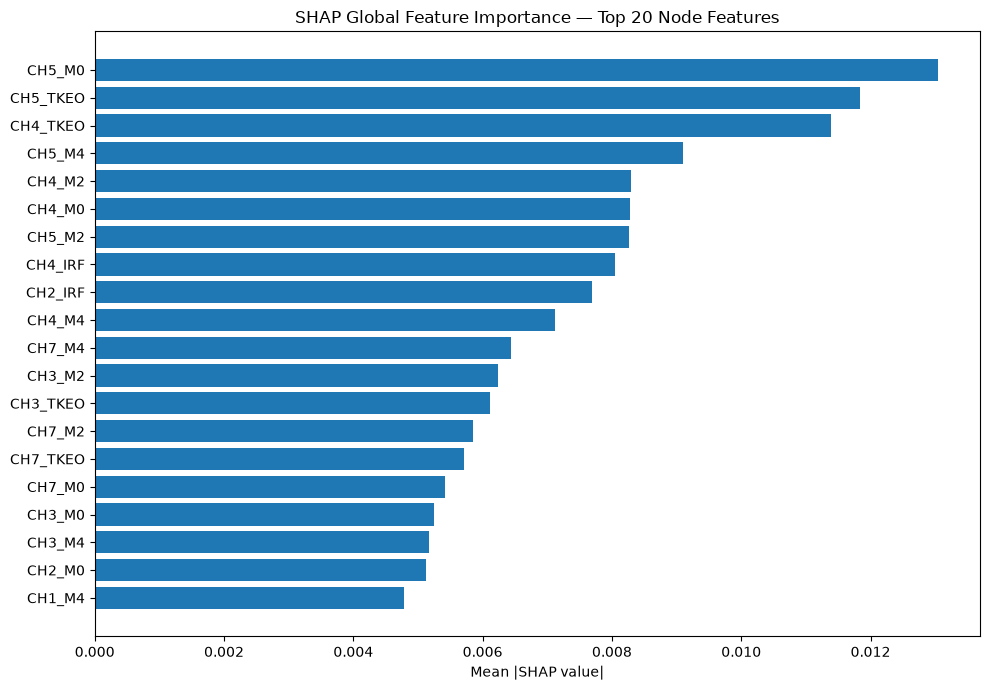


Top 5 globally most important features:
 Feature  Mean |SHAP|
  CH5_M0     0.013041
CH5_TKEO     0.011839
CH4_TKEO     0.011388
  CH5_M4     0.009093
  CH4_M2     0.008298


In [13]:
# ── Global SHAP feature importance ──────────────────────────────
# Works with both older and newer SHAP output formats.

sv = np.asarray(shap_values_bg)

print("Original SHAP shape:", sv.shape)

if sv.ndim == 3:
    # New SHAP format is commonly:
    # (samples, features, classes)
    #
    # We want mean absolute SHAP across:
    #   samples + classes
    #
    # Result -> (56,)
    shap_abs = np.abs(sv)

    if sv.shape[1] == len(FEATURE_NAMES):
        feature_importance = shap_abs.mean(axis=(0, 2))

    # Alternative format: (samples, classes, features)
    elif sv.shape[2] == len(FEATURE_NAMES):
        feature_importance = shap_abs.mean(axis=(0, 1))

    else:
        raise ValueError(
            f"Cannot identify feature dimension in SHAP array: {sv.shape}"
        )

elif sv.ndim == 2:
    # Single-output SHAP:
    # (samples, features)
    feature_importance = np.abs(sv).mean(axis=0)

elif isinstance(shap_values_bg, list):
    # Older SHAP format:
    # list of (samples, features), one array per class
    feature_importance = np.mean(
        [np.abs(x).mean(axis=0) for x in shap_values_bg],
        axis=0
    )

else:
    raise ValueError(
        f"Unexpected SHAP output format: {type(shap_values_bg)}"
    )

# Final safety check
feature_importance = np.asarray(feature_importance).reshape(-1)

print("Feature importance shape:", feature_importance.shape)
print("Number of feature names:", len(FEATURE_NAMES))

assert len(feature_importance) == len(FEATURE_NAMES), (
    f"Mismatch: {len(feature_importance)} SHAP values "
    f"vs {len(FEATURE_NAMES)} feature names"
)

# Create dataframe
fi_df = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Mean |SHAP|": feature_importance
})

fi_df = (
    fi_df
    .sort_values("Mean |SHAP|", ascending=False)
    .head(20)
)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(
    fi_df["Feature"],
    fi_df["Mean |SHAP|"]
)

plt.xlabel("Mean |SHAP value|")
plt.title("SHAP Global Feature Importance — Top 20 Node Features")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "shap_global_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nTop 5 globally most important features:")
print(fi_df.head(5).to_string(index=False))

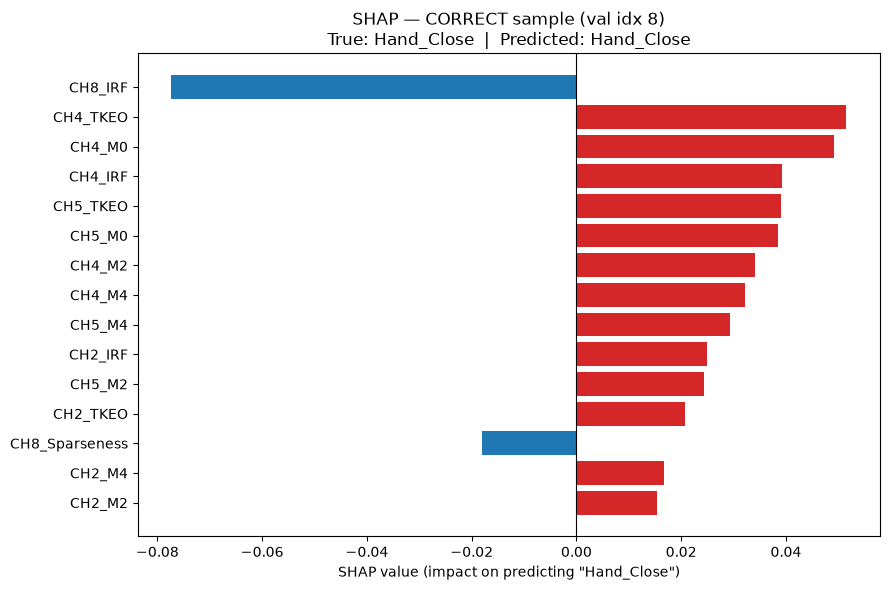

[CORRECT] True=Hand_Close Predicted=Hand_Close
Top contributing features (feature=value -> SHAP contribution):
  CH8_IRF          = -0.607   pushes AWAY FROM "Hand_Close"   (SHAP=-0.0773)
  CH4_TKEO         = +1.121   pushes TOWARD "Hand_Close"   (SHAP=+0.0515)
  CH4_M0           = -0.377   pushes TOWARD "Hand_Close"   (SHAP=+0.0492)
  CH4_IRF          = -0.581   pushes TOWARD "Hand_Close"   (SHAP=+0.0392)
  CH5_TKEO         = +0.863   pushes TOWARD "Hand_Close"   (SHAP=+0.0391)
  CH5_M0           = -0.421   pushes TOWARD "Hand_Close"   (SHAP=+0.0386)
  CH4_M2           = -0.389   pushes TOWARD "Hand_Close"   (SHAP=+0.0340)
  CH4_M4           = -0.356   pushes TOWARD "Hand_Close"   (SHAP=+0.0322)
  CH5_M4           = -0.359   pushes TOWARD "Hand_Close"   (SHAP=+0.0294)
  CH2_IRF          = -0.482   pushes TOWARD "Hand_Close"   (SHAP=+0.0250)
  CH5_M2           = -0.404   pushes TOWARD "Hand_Close"   (SHAP=+0.0243)
  CH2_TKEO         = -0.010   pushes TOWARD "Hand_Close"   (SHAP=+0.0208

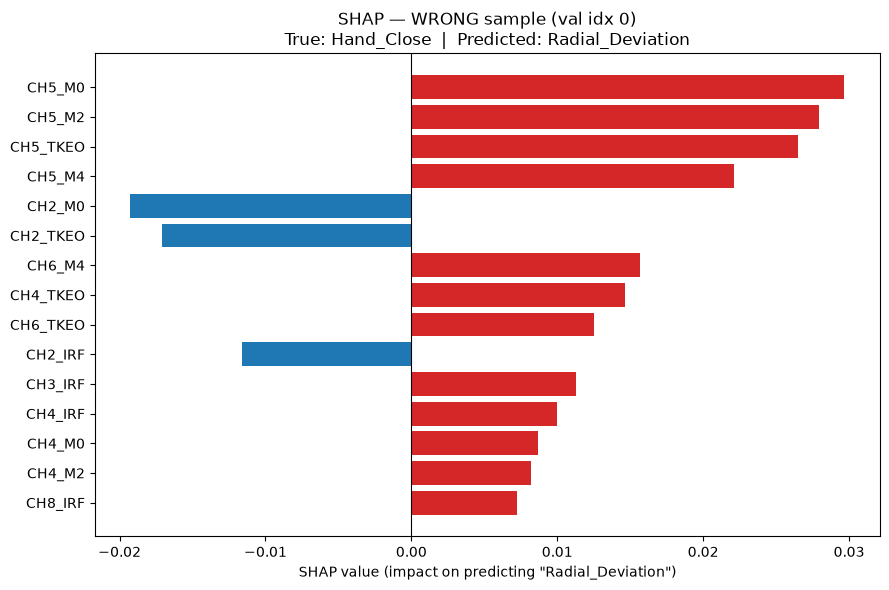

[WRONG] True=Hand_Close Predicted=Radial_Deviation
Top contributing features (feature=value -> SHAP contribution):
  CH5_M0           = -0.492   pushes TOWARD "Radial_Deviation"   (SHAP=+0.0297)
  CH5_M2           = -0.492   pushes TOWARD "Radial_Deviation"   (SHAP=+0.0279)
  CH5_TKEO         = -1.636   pushes TOWARD "Radial_Deviation"   (SHAP=+0.0265)
  CH5_M4           = -0.489   pushes TOWARD "Radial_Deviation"   (SHAP=+0.0221)
  CH2_M0           = -0.391   pushes AWAY FROM "Radial_Deviation"   (SHAP=-0.0193)
  CH2_TKEO         = -1.470   pushes AWAY FROM "Radial_Deviation"   (SHAP=-0.0171)
  CH6_M4           = -0.469   pushes TOWARD "Radial_Deviation"   (SHAP=+0.0156)
  CH4_TKEO         = -0.979   pushes TOWARD "Radial_Deviation"   (SHAP=+0.0147)
  CH6_TKEO         = -0.788   pushes TOWARD "Radial_Deviation"   (SHAP=+0.0125)
  CH2_IRF          = -0.457   pushes AWAY FROM "Radial_Deviation"   (SHAP=-0.0116)
  CH3_IRF          = -0.725   pushes TOWARD "Radial_Deviation"   (SHAP=+0.01

In [15]:
# ── Per-sample SHAP explanation for the CORRECT and WRONG predictions ──

sample_rows = np.array([
    X_shap_v[SAMPLES['CORRECT']],
    X_shap_v[SAMPLES['WRONG']]
])

shap_values_samples = explainer_shap.shap_values(sample_rows)


def plot_shap_sample(label, row_pos, idx, top_k=15):

    true_cls = trues_v[idx]
    pred_cls = preds_v[idx]

    true_g = le.classes_[true_cls]
    pred_g = le.classes_[pred_cls]

    # ── Handle SHAP output format ─────────────────────────────
    # Older SHAP versions:
    #     list[n_classes] -> (n_samples, n_features)
    #
    # Newer SHAP versions:
    #     (n_samples, n_features, n_classes)

    if isinstance(shap_values_samples, list):

        # Old SHAP format
        contrib = shap_values_samples[pred_cls][row_pos]

    else:

        sv = np.asarray(shap_values_samples)

        if sv.ndim == 3:
            # New SHAP format:
            # [sample, feature, class]
            contrib = sv[row_pos, :, pred_cls]

        elif sv.ndim == 2:
            # Binary/single-output SHAP
            contrib = sv[row_pos]

        else:
            raise ValueError(
                f"Unexpected SHAP output shape: {sv.shape}"
            )

    # Actual feature values for this sample
    values = sample_rows[row_pos]

    # ── Select top K features by absolute SHAP value ─────────
    order = np.argsort(-np.abs(contrib))[:top_k]

    feats = [FEATURE_NAMES[i] for i in order]
    contribs = contrib[order]

    # Red = pushes toward prediction
    # Blue = pushes away from prediction
    colors = [
        '#d62728' if c > 0 else '#1f77b4'
        for c in contribs
    ]

    # ── Plot ──────────────────────────────────────────────────
    plt.figure(figsize=(9, 6))

    plt.barh(
        feats,
        contribs,
        color=colors
    )

    plt.gca().invert_yaxis()

    plt.axvline(
        0,
        color='black',
        linewidth=0.8
    )

    plt.xlabel(
        f'SHAP value '
        f'(impact on predicting "{pred_g}")'
    )

    plt.title(
        f'SHAP — {label} sample (val idx {idx})\n'
        f'True: {true_g}  |  Predicted: {pred_g}'
    )

    plt.tight_layout()

    plt.savefig(
        f'shap_{label.lower()}.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    # ── Print explanation ─────────────────────────────────────
    print(
        f'[{label}] True={true_g} '
        f'Predicted={pred_g}'
    )

    print(
        'Top contributing features '
        '(feature=value -> SHAP contribution):'
    )

    for f, v, c in zip(
        feats,
        values[order],
        contribs
    ):

        push = (
            'pushes TOWARD'
            if c > 0
            else 'pushes AWAY FROM'
        )

        print(
            f'  {f:16s} = {v:+.3f}   '
            f'{push} "{pred_g}"   '
            f'(SHAP={c:+.4f})'
        )

    print()


# ── Generate explanations ────────────────────────────────────
plot_shap_sample(
    'CORRECT',
    0,
    SAMPLES['CORRECT']
)

plot_shap_sample(
    'WRONG',
    1,
    SAMPLES['WRONG']
)

## 9 · LIME Explainability

LIME perturbs the 56-dim feature vector locally around each sample and fits a simple linear
model to approximate the **actual trained GNN's** behaviour in that neighbourhood — so, unlike
the SHAP surrogate above, this explanation queries the real GNN directly.


In [16]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_shap_tr,
    feature_names=FEATURE_NAMES,
    class_names=list(le.classes_),
    discretize_continuous=True,
    random_state=42
)

def gnn_predict_flat(X_flat):
    """LIME-compatible predict_proba wrapper for the GNN."""
    X_node = X_flat.reshape(-1, N_CH, 7).astype(np.float32)
    A_fixed = normalize_adj(make_spatial_adj())          # LIME perturbs features, not the graph
    A_batch = np.tile(A_fixed, (len(X_node), 1, 1)).astype(np.float32)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_node), torch.tensor(A_batch)),
        batch_size=256, shuffle=False
    )
    final_model.eval()
    probs = []
    with torch.no_grad():
        for Xb, Ab in loader:
            out = final_model(Xb.to(device), Ab.to(device))
            probs.append(F.softmax(out, dim=-1).cpu().numpy())
    return np.concatenate(probs)

print('LIME explainer ready.')


LIME explainer ready.



[CORRECT] val idx 8  True: Hand_Close  |  Predicted: Hand_Close


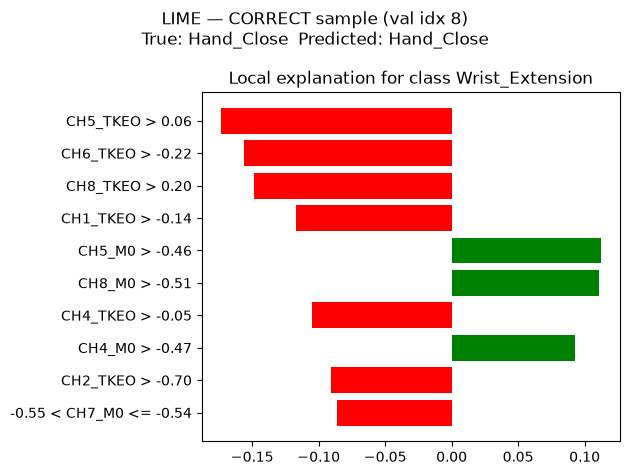


[WRONG] val idx 0  True: Hand_Close  |  Predicted: Radial_Deviation


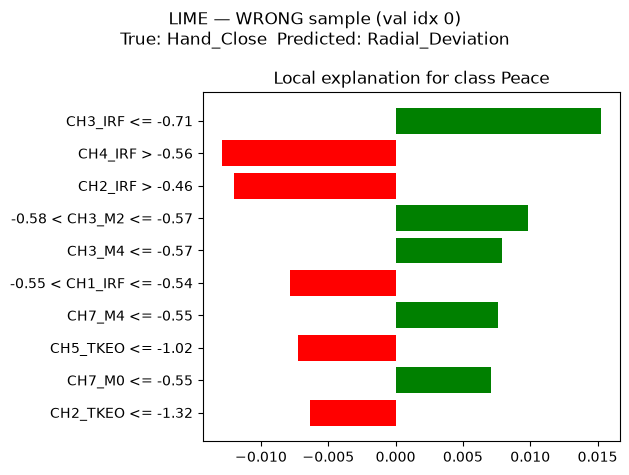

In [17]:
# ── LIME explanation for the SAME two samples used for SHAP ──
lime_explanations = {}

for label, idx in SAMPLES.items():
    exp = lime_explainer.explain_instance(
        X_shap_v[idx],
        gnn_predict_flat,
        num_features=10,
        top_labels=1
    )
    lime_explanations[label] = exp
    true_g = le.classes_[trues_v[idx]]
    pred_g = le.classes_[preds_v[idx]]
    print(f'\n[{label}] val idx {idx}  True: {true_g}  |  Predicted: {pred_g}')
    fig = exp.as_pyplot_figure(label=exp.top_labels[0])
    fig.suptitle(f'LIME — {label} sample (val idx {idx})\nTrue: {true_g}  Predicted: {pred_g}')
    plt.tight_layout()
    plt.savefig(f'lime_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 10 · SHAP vs. LIME — Side-by-Side Comparison

For each of the two samples, we list the top features each method flagged, so agreement
(or disagreement) between the RF-surrogate SHAP explanation and the GNN-native LIME explanation
is easy to read off.


In [22]:
# ── Compare Top-5 SHAP vs Top-5 LIME features ──

import re


def extract_lime_feature(lime_rule, feature_names):
    """
    Extract the actual feature name from a LIME rule.

    Examples:
        CH5_TKEO > 0.06           -> CH5_TKEO
        CH6_TKEO <= -0.22         -> CH6_TKEO
        -0.14 < CH1_TKEO <= 0.20  -> CH1_TKEO
    """

    # Match against the actual feature names first
    for feature in sorted(feature_names, key=len, reverse=True):
        if feature in lime_rule:
            return feature

    # Fallback: feature before comparison operator
    match = re.search(
        r'([A-Za-z0-9_]+)\s*(?:<=|>=|<|>)',
        lime_rule
    )

    if match:
        return match.group(1)

    # Fallback: feature after comparison operator
    match = re.search(
        r'(?:<=|>=|<|>)\s*([A-Za-z0-9_]+)',
        lime_rule
    )

    if match:
        return match.group(1)

    return lime_rule.strip()


for label, idx in SAMPLES.items():

    true_g = le.classes_[trues_v[idx]]
    pred_g = le.classes_[preds_v[idx]]

    print('=' * 70)
    print(
        f'{label} SAMPLE  (val idx {idx})  '
        f'True: {true_g}  |  Predicted: {pred_g}'
    )
    print('=' * 70)

    # CORRECT sample = row 0
    # WRONG sample   = row 1
    row_pos = 0 if label == 'CORRECT' else 1

    # ── SHAP contribution for predicted class ────────────────
    if isinstance(shap_values_samples, list):

        # Older SHAP format:
        # [class][sample][feature]
        contrib = shap_values_samples[preds_v[idx]][row_pos]

    else:

        # Newer SHAP format:
        # [sample][feature][class]
        sv = np.asarray(shap_values_samples)

        if sv.ndim == 3:
            contrib = sv[row_pos, :, preds_v[idx]]

        elif sv.ndim == 2:
            contrib = sv[row_pos]

        else:
            raise ValueError(
                'Unexpected SHAP output shape: '
                + str(sv.shape)
            )

    # ── Top-5 SHAP features ──────────────────────────────────
    top_shap_idx = np.argsort(-np.abs(contrib))[:5]

    top_shap = [
        FEATURE_NAMES[i]
        for i in top_shap_idx
    ]

    # ── Top-5 LIME rules ─────────────────────────────────────
    exp = lime_explanations[label]

    top_lime_rules = exp.as_list(
        label=exp.top_labels[0]
    )[:5]

    # Extract clean feature names
    top_lime_features = []

    for rule, weight in top_lime_rules:
        feature = extract_lime_feature(
            rule,
            FEATURE_NAMES
        )
        top_lime_features.append(feature)

    # ── Find overlap ─────────────────────────────────────────
    shared = set(top_shap) & set(top_lime_features)

    # Keep SHAP ranking for overlap output
    shared_ordered = []

    for feature in top_shap:
        if feature in shared:
            shared_ordered.append(feature)

    # ── Display results ──────────────────────────────────────
    print(
        'Top-5 SHAP features :',
        top_shap
    )

    print(
        'Top-5 LIME rules    :',
        [rule for rule, weight in top_lime_rules]
    )

    print(
        'LIME feature names  :',
        top_lime_features
    )

    if shared_ordered:
        overlap_text = shared_ordered
    else:
        overlap_text = 'none in top-5 (methods disagree)'

    print(
        'Overlap             :',
        overlap_text
    )

    print()

CORRECT SAMPLE  (val idx 8)  True: Hand_Close  |  Predicted: Hand_Close
Top-5 SHAP features : ['CH8_IRF', 'CH4_TKEO', 'CH4_M0', 'CH4_IRF', 'CH5_TKEO']
Top-5 LIME rules    : ['CH5_TKEO > 0.06', 'CH6_TKEO > -0.22', 'CH8_TKEO > 0.20', 'CH1_TKEO > -0.14', 'CH5_M0 > -0.46']
LIME feature names  : ['CH5_TKEO', 'CH6_TKEO', 'CH8_TKEO', 'CH1_TKEO', 'CH5_M0']
Overlap             : ['CH5_TKEO']

WRONG SAMPLE  (val idx 0)  True: Hand_Close  |  Predicted: Radial_Deviation
Top-5 SHAP features : ['CH5_M0', 'CH5_M2', 'CH5_TKEO', 'CH5_M4', 'CH2_M0']
Top-5 LIME rules    : ['CH3_IRF <= -0.71', 'CH4_IRF > -0.56', 'CH2_IRF > -0.46', '-0.58 < CH3_M2 <= -0.57', 'CH3_M4 <= -0.57']
LIME feature names  : ['CH3_IRF', 'CH4_IRF', 'CH2_IRF', 'CH3_M2', 'CH3_M4']
Overlap             : none in top-5 (methods disagree)



### Takeaways

- **Correct sample:** both SHAP (surrogate RF) and LIME (native GNN) should agree on a compact
  set of channel/TSD-statistic features that clearly separate the true gesture from the rest —
  this is what "confident and right" looks like in feature-attribution terms.
- **Wrong sample:** look for either (a) attributions that point to a *different* gesture's
  typical signature (the model was confidently fooled), or (b) weak / conflicting attributions
  (the model was genuinely uncertain). Disagreement between SHAP and LIME on the wrong sample is
  itself informative — it suggests the surrogate RF and the GNN are relying on different cues,
  which is a useful diagnostic for where the GNN's graph-based reasoning diverges from a simple
  flat-feature model.
